# Análise implementação CUDA

**Universidade Estadual de Santa Cruz - UESC**

**Discente:** Everaldina Guimarães Barbosa

**Docente:** Prof. Dr. Esbel Tomas Valero Orellana

**Disciplina:** Processamento Paralelo

## 1. Introdução

Este relatório teve como objetivo analisar o desempenho computacional de um programa desenvolvido em C++, estruturado em duas abordagens: uma sequencial e outro utilizando a arquitetura CUDA para processamento paralelo em GPU. Foram comparados os tempos de execução de uma mesma tarefa nas duas implementações, com o intuito de avaliar a eficiência obtida com o uso de paralelismo em GPU. Além disso, também foi realizada a comparação entre a implementação com MPI e a implementação com OpenMP, que utiliza multithreading.

O sistema consistiu na verificação da similaridade entre pares de tomografias computadorizadas (A e B) tridimensionais, com dimensões representadas por (X, Y, Z). A metodologia do algoritmo baseou-se em extrair o corte central do eixo Z da tomografia A e compará-lo com todos os cortes ao longo do eixo Z da tomografia B. Para quantificar essa correspondência, adotou-se a métrica do Índice de Similaridade Estrutural (SSIM). Ao final da varredura, a aplicação retornava o valor máximo de similaridade detectado, juntamente com o índice numérico do corte da tomografia B correspondente.

Todo o código-fonte, englobando a implementação em C++, os *scripts* de teste, os *notebooks* e os resultados obtidos, encontra-se publicamente disponível no repositório do projeto: [processamento-paralelo](https://github.com/everaldina/processamento-paralelo).

## 2. Metodologia

### 2.1 Conjunto de dados

Os experimentos foram conduzidos utilizando o conjunto de dados *OrcaScore*, que dispõe de 72 pares de tomografias computadorizadas cardíacas. Cada par é constituído por uma imagem capturada com injeção de contraste e outra sem contraste, ambas possuindo dimensões de (512, 512, Z). A profundidade Z varia: entre 167 e 640 cortes para as imagens com contraste, e entre 36 e 64 cortes para as imagens sem contraste.

A base é originalmente dividida em três subconjuntos: treino (32 pares), teste (32 pares) e validação (8 pares), cujas aquisições vinham de quatro tomógrafos distintos, designados como V1, V2, V3 e V4. Visando otimizar o tempo de processamento e viabilizar a execução de todos os cenários de teste, os exames originários do equipamento V2 foram restritos apenas ao conjunto de validação, reduzindo a amostra total analisada para 56 pares. Essa restrição foi adotada porque as tomografias com contraste do equipamento V2 apresentavam um volume de cortes superior (mínimo de 480 cortes) em comparação aos demais (máximo de 380 cortes), o que elevaria o custo computacional a níveis que inviabilizariam os prazos do projeto.

### 2.2 Indice de Similaridade Estrutural (SSIM)

A lógica de cálculo do SSIM foi fundamentada na implementação da biblioteca *scikit-image*, nativa da linguagem Python, especificamente no módulo [structural_similarity](https://github.com/scikit-image/scikit-image/blob/main/src/_skimage2/metrics/_structural_similarity.py). O código Python de referência foi preservado no momento da implementação em C++ no arquivo [function_base.py](ref_codes/function_base.py) presente no repositório do projeto.

Foi realizada uma tradução direta do código em Python para C++, visando assegurar a mesma fidelidade matemática no programa principal. Essa implementação pode ser encontrada no arquivo [ssim_impl.hpp](src\metrics\ssim_impl.hpp).

### 2.3 Resumo de implementação

Diferentemente das abordagens anteriores, que distribuíam cortes inteiros da imagem B entre threads (OpenMP) ou processos (MPI), a implementação em CUDA explorou dois níveis de paralelismo simultaneamente:

- Nível de bloco (_grid_): cada bloco de threads ficou responsável por processar o SSIM entre a fatia central de A e um único corte de B. O número de blocos lançados é exatamente igual ao número de cortes de B (cortes_B).
- Nível de _thread_ (dentro do bloco): dentro de cada bloco, os pixels válidos daquele corte foram divididos entre as threads do bloco, cada uma responsável por um subconjunto de pixels e por acumular sua contribuição parcial para a média final do SSIM daquele corte.

Assim como nas demais versões, o número de repetições por par e a dupla verificação (A sem contraste vs. B com contraste, e vice-versa) foram mantidos. O kernel size e o número de threads por bloco foram passados como parâmetros de linha de comando (`-k` e `-t`), sem um equivalente ao batch_size/size_parallel do OpenMP, já que aqui a granularidade de distribuição do trabalho é fixa: um bloco por corte de B.

Em pseudocódigo, a estrutura principal do programa manteve o mesmo padrão de iteração:

```bash
para id em lista_de_ids:
    caminho_imagem_A = id + "_sem_contraste"
    caminho_imagem_B = id + "_com_contraste"

    para repeticao em numero_de_repeticoes:
        resultado = comparar_imagens(caminho_imagem_A, caminho_imagem_B, kernel, threads_por_bloco)

    caminho_imagem_A = id + "_com_contraste"
    caminho_imagem_B = id + "_sem_contraste"

    para repeticao em numero_de_repeticoes:
        resultado = comparar_imagens(caminho_imagem_A, caminho_imagem_B, kernel, threads_por_bloco)
```


A leitura das imagens seguiu a mesma implementação em [mhd_reader.hpp](src/image_reader/mhd_reader.hpp), garantindo que o volume B fosse armazenado em um único bloco contíguo de memória. Essa contiguidade foi essencial também na GPU, ao copiar o volume inteiro de uma só vez para a memória de vídeo, cada bloco pôde calcular o deslocamento do seu próprio corte apenas multiplicando o índice do bloco pelo tamanho de um corte, garantindo acessos coalescidos à memória global e evitando múltiplas transferências pequenas (uma por corte), que seriam bem mais lentas que uma única transferência grande.

Três buffers eram alocados na GPU: a fatia central de A, o volume inteiro de B e um vetor de resultados (um double por corte de B). Após a cópia _host_ → _device_ de A e B, a cópia do volume B na CPU já podia ser liberada, economizando RAM — mesma estratégia adotada nas versões OpenMP/MPI.

Em pseudocódigo, a função comparar_imagens (lado host) ficou assim:

```bash
inicio_comparacao = tempo_atual()
inicio_leitura = tempo_atual()

imagem_A = ler_imagem(caminho_imagem_A)
imagem_B = ler_imagem(caminho_imagem_B)
corte_central_A = selecionar_corte_central(imagem_A)

se memoria_necessaria(imagem_B) > memoria_livre_gpu():
    abortar_par("memoria insuficiente na GPU")

centralA_gpu    = alocar_gpu(tamanho_corte)
volumeB_gpu     = alocar_gpu(tamanho_volume_B)
resultados_gpu  = alocar_gpu(cortes_B * tamanho_double)

copiar_para_gpu(centralA_gpu, corte_central_A)
copiar_para_gpu(volumeB_gpu, imagem_B)
liberar_memoria_host(imagem_B)

fim_leitura = tempo_atual()
tempo_leitura = fim_leitura - inicio_leitura

inicio_busca = tempo_atual()
memoria_compartilhada = threads_por_bloco * tamanho_double
lancar_kernel_ssim<<<cortes_B, threads_por_bloco, memoria_compartilhada>>>(
    centralA_gpu, volumeB_gpu, largura, altura, kernel, data_range, resultados_gpu
)
sincronizar_gpu()

resultados_ssim = copiar_para_cpu(resultados_gpu)
liberar_memoria_gpu(centralA_gpu, volumeB_gpu, resultados_gpu)

maior_similaridade = -1
numero_do_corte_B = -1
para i, ssim em resultados_ssim:
    se ssim > maior_similaridade:
        maior_similaridade = ssim
        numero_do_corte_B = i
fim_busca = tempo_atual()

tempo_busca = fim_busca - inicio_busca
fim_comparacao = tempo_atual()
tempo_avg_slice = tempo_busca / cortes_B
tempo_total = fim_comparacao - inicio_comparacao
```

O núcleo do processamento paralelo, no entanto, ocorre dentro do kernel [ssim_kernel](src\metrics\ssim_kernel.cuh), executado por todos os blocos e threads simultaneamente na GPU. Cada bloco identifica o corte de B que lhe cabe a partir de `blockIdx.x` e calcula o deslocamento desse corte dentro do volume contíguo:

```cpp
    int slice_index = blockIdx.x;
    const short* image_b = volume_b + static_cast<std::size_t>(slice_index) * width * height;
```

Dentro do bloco, cada thread percorre um subconjunto dos pixels válidos daquele corte, em passos de tamanho `blockDim.x`, o que é necessário porque o número de pixels válidos de uma fatia (por exemplo, ~250 mil pixels em uma imagem 512×512) é, em geral, muito maior que o número de threads disponíveis por bloco (no máximo 1024). Para cada pixel, a thread computa as somas da janela deslizante necessárias para a fórmula do SSIM local, acumulando o resultado em um registrador próprio.

Ao término do laço, cada thread grava sua soma parcial em uma posição própria de um vetor em memória compartilhada (`partial_sums[threadIdx.x]`), com uma barreira de sincronização (`__syncthreads()`) garantindo que todas as threads do bloco tenham terminado de escrever antes da etapa seguinte. A soma final do corte é então obtida por uma redução em árvore: a cada iteração, o tamanho do passo (stride) é reduzido pela metade, e apenas as threads com índice menor que o stride somam o valor localizado stride posições à frente, seguidas de nova sincronização — até restar em `partial_sums[0]` a soma de todas as contribuições do bloco:

```cpp
partial_sums[threadIdx.x] = thread_ssim_sum;
__syncthreads();

for (unsigned int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
    if (threadIdx.x < stride)
        partial_sums[threadIdx.x] += partial_sums[threadIdx.x + stride];
    __syncthreads();
}

if (threadIdx.x == 0) {
    ssim_per_slice[slice_index] = (valid_pixel_count > 0)
                                       ? (partial_sums[0] / static_cast<double>(valid_pixel_count))
                                       : 0.0;
}
```


Esse esquema de bisseção do stride só cobre corretamente todos os elementos do vetor quando o tamanho do bloco (`blockDim.x`) é uma potência de 2, partindo de `stride = blockDim.x / 2` e dividindo sucessivamente por 2, cada posição é somada exatamente uma vez até restar apenas o índice 0.  Por esse motivo, o número de threads por bloco informado via linha de comando é sempre arredondado para a próxima potência de 2, limitado a 1024 (o máximo suportado por bloco na arquitetura CUDA):

```bash
int round_up_pow2(int value) {
    if (value < 1) value = 1;
    int powered = 1;
    while (powered < value) powered <<= 1;
    return powered;
}
// ...
int adjusted = round_up_pow2(threads_per_block);
if (adjusted > 1024) adjusted = 1024;
```


Durante os testes, foi observado um teto de desempenho (performance cap) que não respondia ao aumento do número de threads por bloco nem ao número de blocos lançados — indício de que o gargalo não estava na quantidade de paralelismo exposto, mas em uma limitação da própria unidade de execução da GPU.

A causa é o uso de aritmética em dupla precisão (double) em todo o cálculo do SSIM dentro do kernel (somas, médias, variância e covariância). GPUs da linha GeForce, voltadas ao mercado consumidor/gamer — como a GTX 1060 usada nos testes —, possuem deliberadamente uma proporção muito baixa de unidades de ponto flutuante de dupla precisão (FP64) em relação às de precisão simples (FP32): na arquitetura Pascal, essa razão é de aproximadamente 1/32, contra 1/2 em placas profissionais/datacenter (Tesla) da mesma geração — a fabricante restringe o FP64 do segmento consumidor de propósito, para diferenciá-lo das linhas voltadas a computação científica. Na prática, isso significa que cada operação em double dispõe de uma fração muito menor de unidades de execução que a mesma operação em float, criando um gargalo de throughput que nenhum nível adicional de paralelismo consegue contornar, já que o limitante passa a ser a disponibilidade de unidades FP64, e não a quantidade de threads em voo.

Diante disso, mostrou-se necessário considerar a conversão dos cálculos internos do SSIM para precisão simples (float), preservando short apenas para os pixels de entrada (sem perda de informação, já que os valores de intensidade não exigem a faixa dinâmica do double), de modo a explorar toda a capacidade de processamento em ponto flutuante da GTX 1060 e obter ganhos de desempenho de fato proporcionais ao paralelismo empregado. Por conta disso o teste de corretude usou uma tolerancia menos estrita para a comparação entre os resultados obtidos com o metodo sequencial e o metodo paralelo, considerando que a precisão simples (float) tem uma faixa de valores representáveis menor que a precisão dupla (double), e portanto pode gerar pequenas diferenças nos resultados finais.

Todo o processamento gerava saídas formatadas em logs de texto, contendo os IDs das imagens, o kernel, o número de threads por bloco, a quantidade de cortes de B avaliados e os tempos obtidos (leitura, busca e total), seguindo o mesmo padrão das demais versões. O tempo de escrita nos arquivos foi isolado propositalmente para não impactar as métricas de comparação de desempenho do sistema.

### 2.4 Testes realizados

A execução da versão sequencial englobou os 72 pares de imagens originais, testados sob os *kernels* 3, 5, 7 e 9. Cada combinação de imagem e *kernel* foi executada 10 vezes com a alternância das imagens A e B, resultando em 5.760 testes globais. Foi feito um teste de corretude, comparando diretamente as saídas computadas em C++ com uma réplica implementada em Python, garantindo a fidelidade do algoritmo. Esses testes podem ser encontrados no arquivo [omp_parallel.ipynb](notebooks/omp_parallel.ipynb), no repositório do projeto.

Para a abordagem CUDA, limitou-se o escopo aos *kernels* 5, 7 e 9 e a 5 repetições por par, com a filtragem de dados descrita na seção 2.1. Para cada *kernel*, foram empregados diferentes de threads por bloco: 32, 64, 128, 256, 512 e 1024. O número de blocos lançados é sempre igual ao número de cortes de B, que varia de acordo com o par de imagens.

Após a realização dos testes com CUDA, todos os resultados voltaram a ser comparados com os resultados da versão sequencial, garantindo a integridade do processamento paralelo.

Também foi realizada a comparação entre os tempos de execução da versão MPI e da versão OpenMP, com o intuito de avaliar a eficiência do processamento paralelo em ambas as abordagens.

Para comparação de performance, foram utilizados as metricas de speedup e eficiência, definidas como:

- **Speedup**: razão entre o tempo de execução da versão sequencial e o tempo de execução da versão paralela, para um mesmo *kernel* e par de imagens.
- **Eficiência**: razão entre o speedup e o número de processos (ou *threads*), para um mesmo *kernel* e par de imagens.

Na implementação existe 3 tempos registrados: tempo total, tempo de leitura e tempo de busca. O tempo de leitura é o tempo gasto para ler os arquivos de imagem do disco e distribuir os dados entre os processos. O tempo de busca é o tempo gasto para calcular o SSIM e encontrar o corte correspondente. O tempo total é a soma do tempo de leitura e do tempo de busca. Para a análise de performance, foram utilizados os tempos totais e os tempos de busca, isolando o tempo de leitura para não impactar as métricas de comparação.

### 2.5 Hardware e software utilizados

A execução de todos os testes ocorreu em uma máquina equipada com processador AMD Ryzen 5 5500 @ 3.60GHz (6 núcleos físicos, 12 núcleos lógicos), 16 GB de memória RAM e GPU Nvidia GeForce GTX 1060 6GB, executando o sistema operacional Ubuntu via WSL. O compilador adotado foi o `nvcc` (via MinGW) com a flag `-O3` para o nível máximo de otimização de código.

## 3. Resultados

- Preparação do ambiente

In [1]:
import os
from log_utils import read_log, parse_log
from corretude import teste_corretude
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
OUTPUT_DIR = os.path.join('..', 'output')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 3.1 Teste de Corretude

Para validar a corretude da implementação CUDA, foram comparados os resultados obtidos com a versão sequencial, os quais foram anteriormente validados com a implementação em Python.

A comparação foi realizada utilizando o *script* `notebooks/corretude.py`, que recebe dois dataframes contendo os resultados de cada versão, e verifica se:

1. Há apenas um valor máximo de SSIM para cada par de imagens, garantindo que o algoritmo não tenha retornado múltiplos valores máximos.
2. Há apenas um índice de corte correspondente ao valor máximo de SSIM, assegurando que o algoritmo tenha identificado corretamente o corte da imagem B que apresenta a maior similaridade com a imagem A.
3. Os valores máximos de SSIM são iguais ou muito próximos entre as duas versões, considerando uma tolerância padrão de 1e-25. Como a implementação CUDA utiliza aritmética de precisão simples (float) para os cálculos internos do SSIM, a tolerância foi ajustada para 1e-5, permitindo pequenas diferenças nos resultados finais devido à menor faixa de valores representáveis.

In [3]:
# Lendo logs sequenciais
file_path = os.path.join(OUTPUT_DIR, 'sequencial.txt')
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        log_content = f.read()
    sequencial = parse_log(log_content)
    df_seq = pd.DataFrame(sequencial)
else:
    print(f"Arquivo {file_path} não encontrado.")

In [4]:
df_seq['threads'] = None
df_seq['type'] = 'sequencial'

In [5]:
data_frames = []
threads_by_block = [32, 64, 128, 256, 512, 1024]
kernels = [5, 7, 9]
tolerance = 1e-5

In [6]:
### leitura mpi ###
for t in threads_by_block:
    for kernel in kernels:
        filename = f"cuda_t{t}_k{kernel}.txt"
        filepath = os.path.join(OUTPUT_DIR, filename)
        if os.path.exists(filepath):
            log_content = read_log(filepath)
            df = parse_log(log_content)
            data_frames.append(df)
            df['threads'] = t
            df['type'] = 'cuda'
            data_frames.append(df)
        else:
            print(f"Arquivo {filename} não encontrado.")

df_cuda = pd.concat(data_frames, ignore_index=True)

In [7]:
result = teste_corretude(df_ref = df_seq[df_seq['windows_size'] == '5'],
                         df_comp = df_cuda[df_cuda['windows_size'] == '5'], 
                         lista_ids = df_cuda['id'].unique(), 
                         nome_ref = 'Sequencial', 
                         nome_comp = 'CUDA',
                         tolerance_ssim = tolerance)
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [8]:
result = teste_corretude(df_ref = df_seq[df_seq['windows_size'] == '7'],
                         df_comp = df_cuda[df_cuda['windows_size'] == '7'], 
                         lista_ids = df_cuda['id'].unique(), 
                         nome_ref = 'Sequencial', 
                         nome_comp = 'CUDA',
                         tolerance_ssim = tolerance)
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


In [9]:
result = teste_corretude(df_ref = df_seq[df_seq['windows_size'] == '9'],
                         df_comp = df_cuda[df_cuda['windows_size'] == '9'], 
                         lista_ids = df_cuda['id'].unique(), 
                         nome_ref = 'Sequencial', 
                         nome_comp = 'CUDA',
                         tolerance_ssim = tolerance)
print(f"Total de comparações: {result['num_comp']}")
print(f"Diferenças encontradas nos melhores cortes: {result['num_index_diff']}")
print(f"Diferenças encontradas nos valores de SSIM: {result['num_ssim_diff']}")

ID TRV1P1 | Cortes 280
  - Resultados consistentes
ID TRV1P1 | Cortes 64
  - Resultados consistentes
ID TRV1P2 | Cortes 56
  - Resultados consistentes
ID TRV1P2 | Cortes 182
  - Resultados consistentes
ID VAV4P1 | Cortes 48
  - Resultados consistentes
ID VAV4P1 | Cortes 348
  - Resultados consistentes
ID VAV4P2 | Cortes 48
  - Resultados consistentes
ID VAV4P2 | Cortes 332
  - Resultados consistentes
Total de comparações: 112
Diferenças encontradas nos melhores cortes: 0
Diferenças encontradas nos valores de SSIM: 0


Para todos os pares de imagens testados, a implementação CUDA passou nos testes de corretude, confirmando que os resultados obtidos são consistentes com a versão sequencial e com a implementação em Python.

## 3.2 Comparação de resultados entre execução serial e CUDA

In [12]:
df_seq = df_seq[df_seq['windows_size'].isin(['5', '7', '9'])]
mask_val = df_seq['id'].str.contains('VA')
df_val = df_seq[mask_val]
df_non_val = df_seq[~mask_val]
df_non_val = df_non_val[~df_non_val['id'].str.contains('V2')]
df_seq_trimmed = pd.concat([df_val, df_non_val], ignore_index=True)

In [13]:
df_final = pd.concat([df_cuda, df_seq_trimmed], ignore_index=True)
df_final['threads'] = df_final['threads'].astype(float)

In [14]:
colunas_agrupamento = ['id', 'cortes', 'threads', 'type', 'windows_size']
colunas_tempo = ['tempo_leitura', 'tempo_medio_slice', 'tempo_busca', 'tempo_total']

df_medio = df_final.groupby(colunas_agrupamento, dropna=False)[colunas_tempo].mean().reset_index()

In [15]:
# separacao de dados sequenciais
df_seq = df_medio[df_medio['type'] == 'sequencial'].copy()
df_seq = df_seq[['id', 'tempo_total', 'tempo_busca', 'windows_size', 'cortes']].rename(columns={'tempo_total': 'tempo_total_seq', 'tempo_busca': 'tempo_busca_seq'})

# separacao de dados paralelos
df_par = df_medio[df_medio['type'] != 'sequencial'].copy()

# juncao dos dados sequenciais e paralelos para analise de speedup e eficiencia
df_analise = df_par.merge(df_seq, on=['id', 'windows_size', 'cortes'], how='inner')

# calculo de speedup e eficiencia
df_analise['speedup_total'] = df_analise['tempo_total_seq'] / df_analise['tempo_total']
df_analise['speedup_busca'] = df_analise['tempo_busca_seq'] / df_analise['tempo_busca']

O tempo total de execução com a implementação CUDA passou, em média, de 4.36 segundos para 1.22 segundos, representando um speedup médio de 3.27x. O maior speedup médio foi de 6.90x, enquanto o menor foi de 1.27x. Porém, ao olhar apenas para o tempo de busca, que é a parte paralelizada, o desempenho médio é muito superior, com speedup médio de 86.45x, sendo o maior speedup de 165x e o menor de 11.27x. Isso indica que o programa está limitado pelo tempo de leitura, que não é paralelizado.

In [16]:
df_analise[['tempo_busca', 'tempo_total', 'tempo_total_seq', 'tempo_busca_seq', 'speedup_total', 'speedup_busca']].describe()

,tempo_busca,tempo_total,tempo_total_seq,tempo_busca_seq,speedup_total,speedup_busca
count,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000,2016.000000
mean,0.038497,1.222961,4.357489,3.528089,3.273536,86.448905
std,0.026782,0.407613,3.171893,3.106206,1.615127,33.303120
min,0.005323,0.529811,1.049966,0.440187,1.267823,11.274233
25%,0.014770,0.887961,1.799555,0.991309,1.922436,62.939297
50%,0.034823,1.148610,2.813547,2.020804,2.804074,89.658946
75%,0.053862,1.486946,6.631773,5.804201,4.443992,111.850273
max,0.185593,2.631287,17.012600,15.705342,6.905011,164.990622


É possível visualizar, pela tabela e pelo gráfico abaixo, o comportamento da implementação CUDA para cada tamanho de janela e também a influência que a quantidade de threads por bloco tem no desempenho do programa.

Olhando para o speedup total, é possível observar que ele não é muito alto, tendo maior valor de 4.44x e menor valor de 2.20x. Porém, como visto anteriormente, o tempo de leitura não é paralelizado, então a aceleração do programa é limitada por esse tempo, e o speedup total não reflete o desempenho real da parte paralelizada do programa. Ao olhar para o speedup da parte paralelizada, que é a busca, o desempenho é muito superior, tendo como maior valor 114.4032 e menor valor 47.6665.

O maior speedup está no número de 256 threads por bloco; a partir desse ponto, há uma leve queda no desempenho, porém essa queda continua de forma linear. Já com menos de 256 threads por bloco, o desempenho cai de forma acentuada, sendo 32 o pior caso. Isso indica que a quantidade de threads por bloco influencia o desempenho do programa: com um número menor de threads, o programa não consegue aproveitar toda a capacidade de paralelismo do hardware; a partir de um certo ponto, no entanto, aumentar ainda mais a quantidade de threads não traz ganhos adicionais de desempenho, possivelmente por conta do overhead de gerenciamento das threads.


Em termos de kernel, o desempenho da implementação CUDA aumentou para os kernels maiores. Isso se dá porque a própria implementação sequencial tem um desempenho que vai piorando muito com o aumento do tamanho da janela, e a implementação CUDA consegue aproveitar melhor o paralelismo do hardware para kernels maiores. O kernel de tamanho 5, por exemplo, é o que apresenta os menores valores de speedup, enquanto o kernel de tamanho 9 é o que apresenta os maiores valores.


In [17]:
resumo_by_kernel = df_analise.groupby(['threads', 'windows_size']).agg(
    tempo_total_medio=('tempo_total', 'mean'),
    tempo_total_medio_seq=('tempo_total_seq', 'mean'),
    tempo_busca_medio=('tempo_busca', 'mean'),
    tempo_busca_medio_seq=('tempo_busca_seq', 'mean'),
    speedup_medio_total=('speedup_total', 'mean'),
    speedup_medio_busca=('speedup_busca', 'mean')
).reset_index()

resumo_by_kernel['speedup_medio_total'] = resumo_by_kernel['speedup_medio_total'].round(4)
resumo_by_kernel['tempo_total_medio'] = resumo_by_kernel['tempo_total_medio'].round(4)
resumo_by_kernel['tempo_total_medio_seq'] = resumo_by_kernel['tempo_total_medio_seq'].round(4)
resumo_by_kernel['tempo_busca_medio'] = resumo_by_kernel['tempo_busca_medio'].round(4)
resumo_by_kernel['tempo_busca_medio_seq'] = resumo_by_kernel['tempo_busca_medio_seq'].round(4)
resumo_by_kernel['speedup_medio_busca'] = resumo_by_kernel['speedup_medio_busca'].round(4)

resumo_by_kernel.sort_values(by=['threads', 'windows_size'])

,threads,windows_size,tempo_total_medio,tempo_total_medio_seq,tempo_busca_medio,tempo_busca_medio_seq,speedup_medio_total,speedup_medio_busca
0,32.0,5,1.2152,2.8519,0.0381,2.0218,2.1991,47.6665
1,32.0,7,1.2491,4.2865,0.0498,3.4582,3.1567,61.7238
2,32.0,9,1.2552,5.9341,0.0726,5.1043,4.3200,61.3473
3,64.0,5,1.2192,2.8519,0.0314,2.0218,2.1914,56.6398
4,64.0,7,1.2299,4.2865,0.0400,3.4582,3.2073,76.3207
5,64.0,9,1.2466,5.9341,0.0607,5.1043,4.3362,74.0065
6,128.0,5,1.2085,2.8519,0.0268,2.0218,2.2093,71.1769
7,128.0,7,1.2009,4.2865,0.0312,3.4582,3.2900,102.4036
8,128.0,9,1.2190,5.9341,0.0440,5.1043,4.4395,106.8576
9,256.0,5,1.2177,2.8519,0.0241,2.0218,2.1930,82.0635


In [18]:
def plot_thread_comparison(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))

    title = f'Resultados de Speedup'
    fig.suptitle(title, fontsize=16)
    
    sns.lineplot(
        data=df, 
        x='threads', 
        y='speedup_busca', 
        hue='windows_size',
        marker='o',
        palette='Set1',
        ax=ax,
    )
    
    ax.set_title('Speedup vs Threads by block', fontsize=14)
    ax.set_xlabel('Threads by block', fontsize=12)
    ax.set_ylabel('Speedup (Vezes mais rápido)', fontsize=12)
    ax.axhline(1, ls='--', color='gray', label='Speedup 1 (Sequencial)')
    ax.legend(title='Threads')

    plt.tight_layout()
    plt.show()

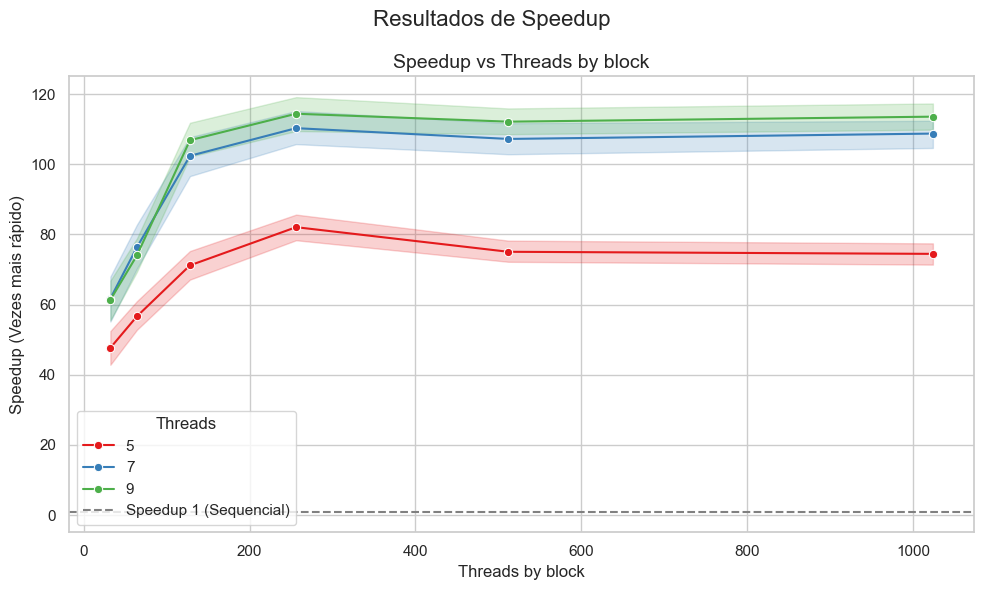

In [19]:
plot_thread_comparison(df_analise)

In [20]:
resumo_by_kernel.sort_values(by=['windows_size', 'threads'])

,threads,windows_size,tempo_total_medio,tempo_total_medio_seq,tempo_busca_medio,tempo_busca_medio_seq,speedup_medio_total,speedup_medio_busca
0,32.0,5,1.2152,2.8519,0.0381,2.0218,2.1991,47.6665
3,64.0,5,1.2192,2.8519,0.0314,2.0218,2.1914,56.6398
6,128.0,5,1.2085,2.8519,0.0268,2.0218,2.2093,71.1769
9,256.0,5,1.2177,2.8519,0.0241,2.0218,2.1930,82.0635
12,512.0,5,1.2099,2.8519,0.0261,2.0218,2.2089,75.0482
15,1024.0,5,1.2179,2.8519,0.0267,2.0218,2.1924,74.4556
1,32.0,7,1.2491,4.2865,0.0498,3.4582,3.1567,61.7238
4,64.0,7,1.2299,4.2865,0.0400,3.4582,3.2073,76.3207
7,128.0,7,1.2009,4.2865,0.0312,3.4582,3.2900,102.4036
10,256.0,7,1.2161,4.2865,0.0301,3.4582,3.2460,110.2899


In [23]:
def plot_time_breakdown(df_medio: pd.DataFrame) -> None:
    """
    Compara o tempo sequencial vs Cuda (por threads por block), quebrando cada barra
    em leitura (nao paralelizada) e busca (parte que o MPI acelera), um subplot por kernel.
    """
    df_plot = df_medio.copy()
    df_plot['config'] = df_plot.apply(
        lambda r: 'Sequencial' if r['type'] == 'sequencial' else f"Cuda ({int(r['threads'])}t)",
        axis=1
    )

    resumo = df_plot.groupby(['config', 'windows_size'], as_index=False).agg(
        tempo_leitura=('tempo_leitura', 'mean'),
        tempo_busca=('tempo_busca', 'mean'),
    )

    ordem_config = ['Sequencial'] + sorted(
        [c for c in resumo['config'].unique() if c != 'Sequencial'],
        key=lambda c: int(c.split('(')[1].split('t')[0])
    )
    kernels = sorted(resumo['windows_size'].unique(), key=int)

    fig, axes = plt.subplots(1, len(kernels), figsize=(6 * len(kernels), 6), sharey=True)
    if len(kernels) == 1:
        axes = [axes]
    fig.suptitle('Composição do Tempo: Leitura vs Busca — Sequencial x Cuda', fontsize=16)

    cor_leitura, cor_busca = "#0f7cd0", "#f29d1f"

    for ax, kernel in zip(axes, kernels):
        sub = resumo[resumo['windows_size'] == kernel].set_index('config').reindex(ordem_config)

        ax.bar(sub.index, sub['tempo_leitura'], label='Leitura (serial)', color=cor_leitura)
        ax.bar(sub.index, sub['tempo_busca'], bottom=sub['tempo_leitura'],
               label='Busca SSIM (paralelizável)', color=cor_busca)

        for i, config in enumerate(sub.index):
            total = sub.loc[config, 'tempo_leitura'] + sub.loc[config, 'tempo_busca']
            ax.text(i, total + total * 0.015, f'{total:.2f}s', ha='center', va='bottom', fontsize=9)

        ax.set_title(f'Kernel {kernel}', fontsize=13)
        ax.set_ylabel('Tempo (s)' if ax is axes[0] else '')
        ax.tick_params(axis='x', rotation=20)

    axes[0].legend(loc='upper right')
    plt.tight_layout()
    plt.show()



Ao visualizar o tempo de execução segregado entre leitura e busca, é possível observar que o tempo de leitura permanece praticamente constante, enquanto a implementação CUDA quase zerou o tempo de busca. Isso confirma que o programa está limitado pelo tempo de leitura, que não é paralelizado.

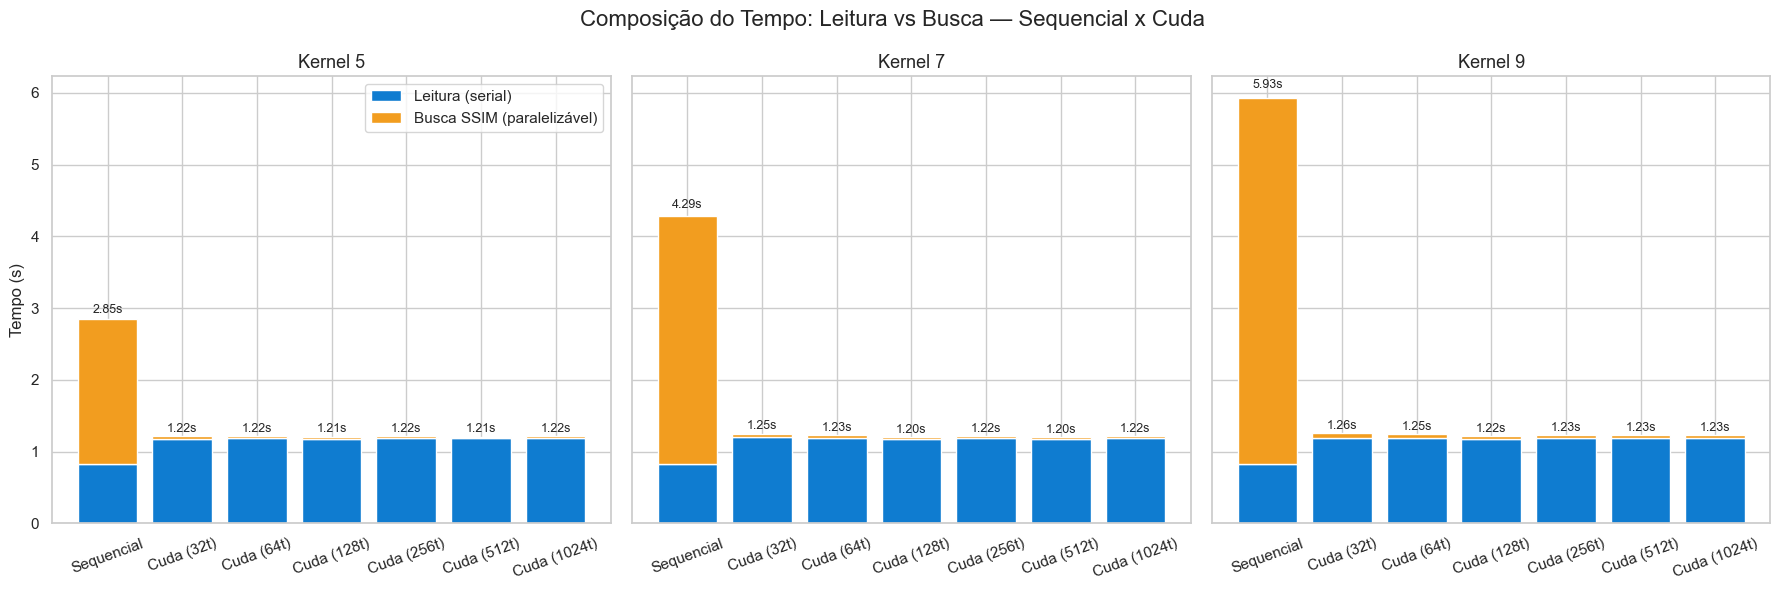

In [24]:
plot_time_breakdown(df_medio)

## 3.3 Comparação de resultados entre execução CUDA, OPenMP e MPI

In [25]:
resumo_by_kernel.sort_values(by=['windows_size', 'speedup_medio_busca'], ascending=[True, False])

,threads,windows_size,tempo_total_medio,tempo_total_medio_seq,tempo_busca_medio,tempo_busca_medio_seq,speedup_medio_total,speedup_medio_busca
9,256.0,5,1.2177,2.8519,0.0241,2.0218,2.1930,82.0635
12,512.0,5,1.2099,2.8519,0.0261,2.0218,2.2089,75.0482
15,1024.0,5,1.2179,2.8519,0.0267,2.0218,2.1924,74.4556
6,128.0,5,1.2085,2.8519,0.0268,2.0218,2.2093,71.1769
3,64.0,5,1.2192,2.8519,0.0314,2.0218,2.1914,56.6398
0,32.0,5,1.2152,2.8519,0.0381,2.0218,2.1991,47.6665
10,256.0,7,1.2161,4.2865,0.0301,3.4582,3.2460,110.2899
16,1024.0,7,1.2190,4.2865,0.0310,3.4582,3.2419,108.7479
13,512.0,7,1.2027,4.2865,0.0307,3.4582,3.2852,107.2178
7,128.0,7,1.2009,4.2865,0.0312,3.4582,3.2900,102.4036


Abaixo, a tabela com os resultados de tempo de execução da busca para a melhor configuração de cada método, e o speedup em relação à implementação sequencial. É possível notar que a abordagem CUDA apresenta um desempenho muito superior em comparação com as implementações OpenMP e MPI, especialmente para tamanhos de kernel maiores. Isso reforça a eficácia do paralelismo massivo oferecido pelas GPUs em tarefas computacionalmente intensivas como o cálculo do SSIM.

| Metodo | Kernel size | tempo de busca (s) | Speedup |
|--------|-------------| -------------| ----------------|
| Sequencial    | 5         |  2.0218         |  - |
| OMP    | 5         |  0.6119          |  2.9199x |
| MPI    | 5         |  0.3303           |  5.246x |
| CUDA   | 5         |  0.0241          |  82.0635x |
| Sequencial    | 7         |  3.4582          |  - |
| OMP    | 7         |  1.1345          |  2.7891x |
| MPI    | 7         |  0.6004          |  5.0888x |
| CUDA   | 7         |  0.0301           |  110.2899x |
| Sequencial    | 9        | 5.1043          |  - |
| OMP    | 9        | 1.5598          |  3.1486x |
| MPI    | 9         | 0.954           |  4.987x |
| CUDA   | 9         | 0.043           |  114.4032x |

## 4. Conclusão

Os resultados obtidos confirmam que a implementação em CUDA foi a abordagem de paralelização mais eficiente entre as testadas, superando de forma expressiva tanto a versão sequencial quanto as versões baseadas em OpenMP e MPI. Ao considerar o tempo de busca — a parcela do algoritmo efetivamente paralelizada — o speedup médio alcançado com CUDA foi de 86.45x, com pico de 165x, enquanto MPI e OpenMP obtiveram, nas melhores configurações, speedups na ordem de 5x e 3x, respectivamente. Esse ganho evidencia a vantagem do paralelismo massivo de GPU frente ao paralelismo de granularidade mais grossa baseado em threads (CPU) ou processos.

Apesar do ganho expressivo no tempo de busca, o speedup total observado (em média 3.27x, variando entre 1.27x e 6.90x) ficou bem abaixo do speedup da busca isoladamente. Isso ocorre porque o tempo de leitura das imagens não é paralelizado, permanecendo praticamente constante entre as versões e passando a ser o principal fator limitante do desempenho geral da aplicação à medida que o tempo de busca se torna cada vez menor. Esse comportamento indica que otimizações futuras deveriam se concentrar também na etapa de leitura de dados, seja através de I/O assíncrono, leitura em paralelo ou pré-carregamento dos volumes.

Em relação à configuração dos parâmetros de execução, o melhor desempenho foi obtido com 256 threads por bloco: valores menores prejudicam sensivelmente o desempenho, por não explorarem adequadamente a capacidade de paralelismo do hardware, enquanto valores maiores apresentam apenas uma leve queda, provavelmente associada ao overhead de gerenciamento das threads. Também foi observado que o ganho de desempenho da implementação CUDA em relação à sequencial cresce com o tamanho do kernel, uma vez que o custo computacional da versão sequencial aumenta mais rapidamente do que o da versão paralela à medida que a janela do SSIM cresce.

Por fim, identificou-se que o desempenho da implementação CUDA estava sendo limitado pelo baixo throughput de operações em dupla precisão (FP64) da GPU utilizada (GTX 1060), característica típica de placas voltadas ao mercado consumidor. Esse fator sugere que a conversão dos cálculos internos do SSIM para precisão simples (float) é um caminho natural para trabalhos futuros, permitindo explorar de forma mais completa a capacidade de processamento em ponto flutuante da GPU e obter ganhos de desempenho ainda mais próximos do potencial teórico do paralelismo empregado. O teste de corretude, realizado com tolerância ajustada para 1e-5 em função dessa mudança de precisão, não identificou divergências relevantes entre os resultados da versão CUDA e da versão sequencial, validando a correção da implementação paralela.